In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [18]:
df = pd.read_csv("../data/processed/cleaned_telco_customer_churn.csv")

# Convert target into numeric
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [19]:
X = df.drop(["customerID", "Churn"], axis=1)

y = df["Churn"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7032, 19)
y Shape: (7032,)


In [20]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

numerical_features = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print()

print("Numerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [21]:
# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor Created Successfully!")

Preprocessor Created Successfully!


In [22]:
# create ML pipeline
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [23]:
def evaluate_model(model, name):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    prediction = pipeline.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    }

In [15]:
pipeline.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [24]:
results = []

results.append(
    evaluate_model(
        LogisticRegression(max_iter=1000),
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        DecisionTreeClassifier(random_state=42),
        "Decision Tree"
    )
)

results.append(
    evaluate_model(
        RandomForestClassifier(random_state=42),
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        "XGBoost"
    )
)

comparison = pd.DataFrame(results)

comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
2,Random Forest,0.787491,0.630662,0.483957,0.547655
3,XGBoost,0.769012,0.571014,0.526738,0.547983
1,Decision Tree,0.730633,0.493369,0.497326,0.495340


In [25]:
best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

best_pipeline.fit(X_train, y_train)

joblib.dump(
    best_pipeline,
    "../models/customer_churn_pipeline.pkl"
)

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [26]:
best_pipeline.predict(X_test[:5])

array([0, 1, 0, 0, 0])

In [27]:
#classification report
from sklearn.metrics import classification_report

y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [28]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[917 116]
 [160 214]]


In [29]:
#confusion matrix visualization
import matplotlib.pyplot as plt

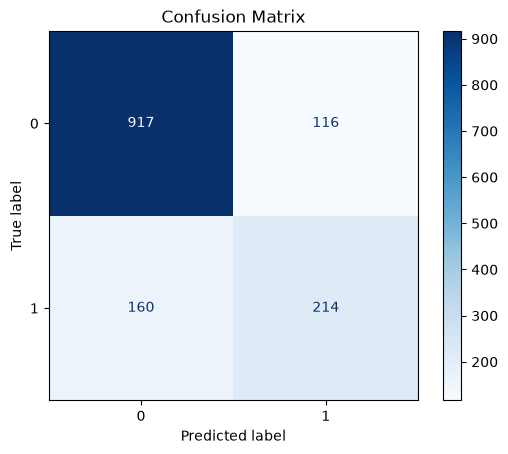

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [31]:
#RUC AUC score
from sklearn.metrics import roc_auc_score

y_prob = best_pipeline.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", roc)

ROC AUC Score: 0.8359290473207676


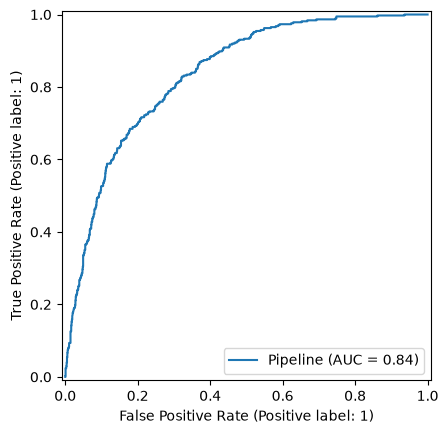

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test
)

plt.show()